# ICLR 2024 Reproduction

This notebook follows the paper order.

By default it reads the results included in this repository from `repro/iclr24/results/paper_release/`. To inspect your own reruns, change the paths in the next cell.


In [1]:
import base64
import json
from html import escape
from pathlib import Path
import os
import sys

import pandas as pd
import torch
from IPython.display import HTML, Markdown, display

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from repro.iclr24.utils.imagenet_data import check_imagenet_prepared
from repro.iclr24.utils.helpers import (
    DEFAULT_ARCHES,
    FIGURE4_PAPER_PDFS,
    FIGURE5_PAPER_PDFS,
    compute_pretrained_pathnorm_dataframe,
    compute_table2_dataframe,
    describe_imp_results_csv,
    describe_increasing_dataset_results_root,
    find_figure4_plot_dir,
    find_figure5_plot_dir,
    find_imp_results_csv,
    load_imp_training_dataframe,
    load_increasing_dataset_dataframe,
    load_pretrained_pathnorm_dataframe,
    summarize_imp_final_epochs,
    summarize_increasing_dataset_final_epoch,
    summarize_margin_quantiles,
)
from repro.iclr24.utils.workflow import (
    figure4_downscaled_rerun_command,
    figure4_rerun_command,
    figure5_downscaled_rerun_command,
    figure5_rerun_command,
    imagenet_download_from_hf_command,
    iclr24_wrapper_script,
    imagenet_prepare_command,
    require_imagenet,
    run_command,
)

ICLR24_ROOT = REPO_ROOT / 'repro' / 'iclr24'
ICLR24_RESULTS_ROOT = ICLR24_ROOT / 'results'
RERUN_RESULTS_ROOT = ICLR24_RESULTS_ROOT / 'rerun'
PAPER_RESULTS_ROOT = ICLR24_RESULTS_ROOT / 'paper_release'
PAPER_PRETRAINED_ROOT = PAPER_RESULTS_ROOT / '1_compute_pretrained_pathnorm_margins_resnets'
IMAGENET_DIR = Path(os.environ.get('IMAGENET_DIR', REPO_ROOT / 'data' / 'imagenet'))
HF_IMAGENET_CACHE_DIR = Path(os.environ.get('HF_IMAGENET_CACHE_DIR', REPO_ROOT / '.hf-cache' / 'imagenet'))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RERUN_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# Change these paths if you want the notebook to read your own reruns.
PRETRAINED_RESULTS_ROOT = PAPER_PRETRAINED_ROOT
FIGURE4_RESULTS_ROOT = PAPER_RESULTS_ROOT
FIGURE5_RESULTS_ROOT = PAPER_RESULTS_ROOT

# Short recomputations
RUN_PRETRAINED_RERUN = False
RUN_PRETRAINED_MARGIN_RERUN = False

# Long training jobs: keep these off in normal notebook use
ALLOW_INTERACTIVE_LONG_RERUN = False
RUN_IMP_DOWNSCALED = False
RUN_IMP_FULL = False
RUN_INCREASING_DOWNSCALED = False
RUN_INCREASING_FULL = False


def repo_relative_path(path):
    path = Path(path)
    try:
        return path.resolve().relative_to(REPO_ROOT.resolve()).as_posix()
    except Exception:
        try:
            return path.relative_to(REPO_ROOT).as_posix()
        except Exception:
            return path.as_posix()


def source_label(selected_root, default_root, label):
    selected_root = Path(selected_root)
    default_root = Path(default_root)
    try:
        if selected_root.resolve() == default_root.resolve():
            return f"{label}: included results"
    except Exception:
        pass
    return f"{label}: {repo_relative_path(selected_root)}"


def display_command_block(title, command):
    display(Markdown(f"**{title}**\n```bash\n{command}\n```"))


def display_plot_grid(pdf_paths, *, columns=2):
    cards = []
    width = 100 / columns
    for pdf_path in pdf_paths:
        if not pdf_path.exists():
            continue
        png_path = pdf_path.with_suffix('.png')
        title = escape(pdf_path.name)
        rel_pdf = escape(repo_relative_path(pdf_path))
        if png_path.exists():
            encoded_png = base64.b64encode(png_path.read_bytes()).decode('ascii')
            preview_html = (
                f"<img src='data:image/png;base64,{encoded_png}' "
                "style='width:100%; border:1px solid #ddd; background:#fff;' />"
            )
        else:
            preview_html = (
                "<div style='padding:24px; border:1px solid #ddd; color:#666; font-size:14px;'>"
                "PNG preview not available. Open the PDF from the results directory."
                "</div>"
            )
        cards.append(
            f"<div style='flex: 1 1 calc({width}% - 12px); min-width: 360px;'>"
            f"<div style='font-weight: 600; margin: 4px 0 8px 0;'>{title}</div>"
            f"{preview_html}"
            f"<div style='margin-top: 6px; color: #666; font-family: monospace; font-size: 12px;'>{rel_pdf}</div>"
            "</div>"
        )
    if cards:
        display(HTML("<div style='display:flex; flex-wrap:wrap; gap:12px;'>" + "".join(cards) + "</div>"))


def show_saved_plot_bundle(plot_dir, pdf_names, *, columns=2, height=None):
    if plot_dir is None:
        print('Saved plot bundle not found.')
        return
    print('Showing saved paper-style plots from', repo_relative_path(plot_dir))
    display_plot_grid([plot_dir / pdf_name for pdf_name in pdf_names], columns=columns)


imagenet_status = check_imagenet_prepared(IMAGENET_DIR)
print('device:', DEVICE)
print('included results:', repo_relative_path(PAPER_RESULTS_ROOT))
print('rerun results:', repo_relative_path(RERUN_RESULTS_ROOT))
print(source_label(PRETRAINED_RESULTS_ROOT, PAPER_PRETRAINED_ROOT, 'pretrained source'))
print(source_label(FIGURE4_RESULTS_ROOT, PAPER_RESULTS_ROOT, 'Figure 4 source'))
print(source_label(FIGURE5_RESULTS_ROOT, PAPER_RESULTS_ROOT, 'Figure 5 source'))
print('ImageNet status:', 'ready' if imagenet_status.prepared else 'not ready')


device: cuda
included results: repro/iclr24/results/paper_release
rerun results: repro/iclr24/results/rerun
pretrained source: included results
Figure 4 source: included results
Figure 5 source: included results
ImageNet status: ready


## Runtime guide

- Table 2 runs in seconds.
- The pretrained path-norm table is a short recomputation and should finish in minutes.
- The appendix margin cell is fast when it reuses the saved tensors. If `RUN_PRETRAINED_MARGIN_RERUN = True`, expect roughly 1-3 hours.
- Figure 4 and Figure 5 are long offline jobs.


## Table 2: first part of the bound


In [2]:
table2_df = compute_table2_dataframe().sort_values('depth').reset_index(drop=True)
display(table2_df.style.format({'bound': '{:.6f}', 'sharpened_bound': '{:.6f}'}))


,arch,depth,bound,sharpened_bound
0,resnet18,18,0.088093,0.059894
1,resnet34,34,0.114522,0.071643
2,resnet50,50,0.135905,0.081720
3,resnet101,101,0.188518,0.107723
4,resnet152,152,0.229364,0.128570


## Tables 3 and 5: pretrained ResNets

In [3]:
RERUN_PRETRAINED_ROOT = RERUN_RESULTS_ROOT / '1_compute_pretrained_pathnorm_margins_resnets'
RERUN_PRETRAINED_ROOT.mkdir(parents=True, exist_ok=True)

pretrained_source_root = RERUN_PRETRAINED_ROOT if RUN_PRETRAINED_RERUN else PRETRAINED_RESULTS_ROOT
pretrained_summary_path = pretrained_source_root / 'pathnorm_summary.csv'
pretrained_metadata_path = pretrained_source_root / 'pathnorm_metadata.json'
pretrained_available = (
    pretrained_summary_path.exists()
    or any((pretrained_source_root / arch / 'pathnorms.pt').exists() for arch in DEFAULT_ARCHES)
)
refresh_pretrained_summary = RUN_PRETRAINED_RERUN or (
    pretrained_source_root == PAPER_PRETRAINED_ROOT
    and (not pretrained_summary_path.exists() or not pretrained_metadata_path.exists())
)

if refresh_pretrained_summary:
    refresh_reason = (
        'RUN_PRETRAINED_RERUN = True'
        if RUN_PRETRAINED_RERUN
        else 'the included bundle is missing the current fp64 summary metadata'
    )
    print(f'Refreshing pretrained path-norm summary in fp64 because {refresh_reason}.')
    try:
        pretrained_df = compute_pretrained_pathnorm_dataframe(
            results_dir=pretrained_source_root,
            device=DEVICE,
        )
    except Exception as exc:
        print(f'Pretrained path-norm refresh failed: {type(exc).__name__}: {exc}')
        if pretrained_available:
            print('Falling back to the saved pretrained tensors already present in the selected source.')
            pretrained_df = load_pretrained_pathnorm_dataframe(pretrained_source_root)
        else:
            pretrained_df = pd.DataFrame()
elif pretrained_available:
    pretrained_df = load_pretrained_pathnorm_dataframe(pretrained_source_root)
else:
    pretrained_df = pd.DataFrame()

if pretrained_df.empty:
    print('No pretrained path-norm artifact was found under the selected source.')
    print('Set RUN_PRETRAINED_RERUN = True to recompute this section into the rerun results directory.')
else:
    if pretrained_source_root == PAPER_PRETRAINED_ROOT:
        print('Using the included pretrained path-norm bundle.')
    else:
        print('Using pretrained path-norm artifacts from', repo_relative_path(pretrained_source_root))
    if pretrained_metadata_path.exists():
        pretrained_metadata = json.loads(pretrained_metadata_path.read_text())
        print('Path-norm summary dtype:', pretrained_metadata.get('working_dtype', 'unknown'))
    pretrained_table = pretrained_df.pivot(index='arch', columns='q', values='pathnorm').reindex(DEFAULT_ARCHES)
    pretrained_log10_table = pretrained_df.pivot(index='arch', columns='q', values='log10_pathnorm').reindex(DEFAULT_ARCHES)

    print('Path-norms')
    display(pretrained_table.style.format('{:.3e}', na_rep='nan'))
    print('log10 path-norms')
    display(pretrained_log10_table.style.format('{:.3f}', na_rep='nan'))


Refreshing pretrained path-norm summary in fp64 because the included bundle is missing the current fp64 summary metadata.
Using the included pretrained path-norm bundle.
Path-norm summary dtype: torch.float64
Path-norms


q,1,2,4,8,16
arch,,,,,
resnet18,1.330e+30,2.436e+03,1.857e-01,6.908e-02,6.201e-02
resnet34,1.890e+51,1.714e+03,1.344e-01,5.191e-02,4.657e-02
resnet50,4.218e+69,1.601e+09,3.765e+00,5.957e-01,3.799e-01
resnet101,2.892e+133,2.343e+10,2.254e+00,6.045e-01,3.681e-01
resnet152,6.014e+194,7.484e+11,1.702e+00,4.265e-01,2.458e-01


log10 path-norms


q,1,2,4,8,16
arch,,,,,
resnet18,30.124,3.387,-0.731,-1.161,-1.208
resnet34,51.276,3.234,-0.872,-1.285,-1.332
resnet50,69.625,9.204,0.576,-0.225,-0.420
resnet101,133.461,10.370,0.353,-0.219,-0.434
resnet152,194.779,11.874,0.231,-0.370,-0.609


## Pretrained results

By default this section reads the pretrained results included in the repository under `repro/iclr24/results/paper_release/1_compute_pretrained_pathnorm_margins_resnets`.

If the included bundle does not yet contain a current summary, this cell refreshes it once with the current `pathnorm` code in `fp64` and saves the refreshed summary beside the included tensors.

If you want to write the refreshed summary to a rerun directory instead, point `PRETRAINED_RESULTS_ROOT` there or set `RUN_PRETRAINED_RERUN = True`.


In [4]:
if pretrained_available:
    if pretrained_source_root == PAPER_PRETRAINED_ROOT:
        print('Pretrained path-norm source: included results.')
    else:
        print('Pretrained path-norm source:', repo_relative_path(pretrained_source_root))
else:
    print('No pretrained path-norm artifacts were found yet.')


Pretrained path-norm source: included results.


## ImageNet preparation for Figures 4 and 5


In [5]:
imagenet_status = check_imagenet_prepared(IMAGENET_DIR)
if not imagenet_status.prepared:
    print('ImageNet is not ready yet.')
    display_command_block(
        'Download the Hugging Face mirror',
        imagenet_download_from_hf_command(IMAGENET_DIR, HF_IMAGENET_CACHE_DIR),
    )
    display_command_block(
        'Stage an existing prepared copy',
        imagenet_prepare_command(IMAGENET_DIR),
    )
else:
    print('ImageNet is ready for the Figure 4 and Figure 5 reruns.')


ImageNet is ready for the Figure 4 and Figure 5 reruns.


## Figure 4: sparse ResNet18 / IMP

By default this section reads the included Figure 4 results and shows the saved paper-style plots. The included bundle uses `40` epochs and `8` pruning iterations. To inspect your own rerun, point `FIGURE4_RESULTS_ROOT` to that results root.


Using Figure 4 results from repro/iclr24/results/paper_release/2_train_imp/seed=0/resnet18/lr=0.1_wd=0.0001_epochs=40_scheduler=multi-step_percentage_pruning=0.2_imp_iters=8/rank=-1/csv/results.csv
Figure 4 settings: epochs=40, pruning iterations=8, rank=-1


,imp_iter,epoch,test/acc1,train/acc1,generalization_error_top1,pathnorm1,pathnorm2,pathnorm4
0,0,40,65.102,62.614,-2.488,2.623e+29,2.342e+02,1.449e-01
1,1,40,65.860,63.552,-2.308,1.172e+29,2.961e+02,1.422e-01
2,2,40,66.352,64.219,-2.133,4.646e+28,3.743e+02,1.403e-01
3,3,40,66.568,64.620,-1.948,1.659e+28,4.622e+02,1.397e-01
4,4,40,66.996,64.936,-2.060,5.739e+27,6.068e+02,1.395e-01
5,5,40,67.062,65.035,-2.027,1.845e+27,8.030e+02,1.414e-01
6,6,40,66.962,65.000,-1.962,5.717e+26,1.113e+03,1.447e-01
7,7,40,66.908,64.834,-2.074,1.683e+26,1.553e+03,1.533e-01
8,8,40,66.542,64.442,-2.100,4.829e+25,2.226e+03,1.628e-01


Showing saved paper-style plots from repro/iclr24/results/paper_release/3_plot_imp/num_seeds=1/resnet18/lr=0.1_wd=0.0001_epochs=40_scheduler=multi-step_percentage_pruning=0.2_imp_iters=8



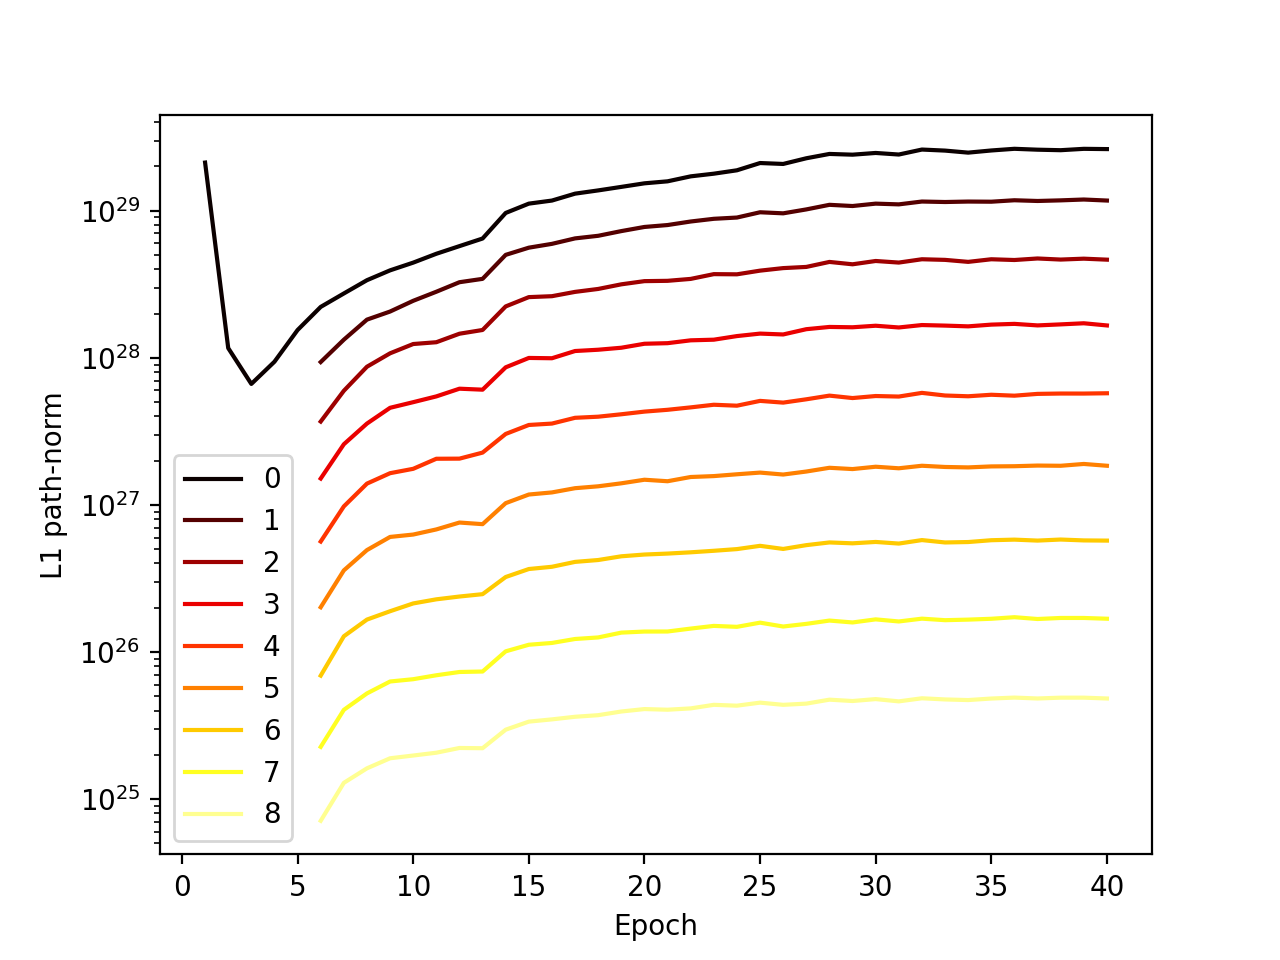
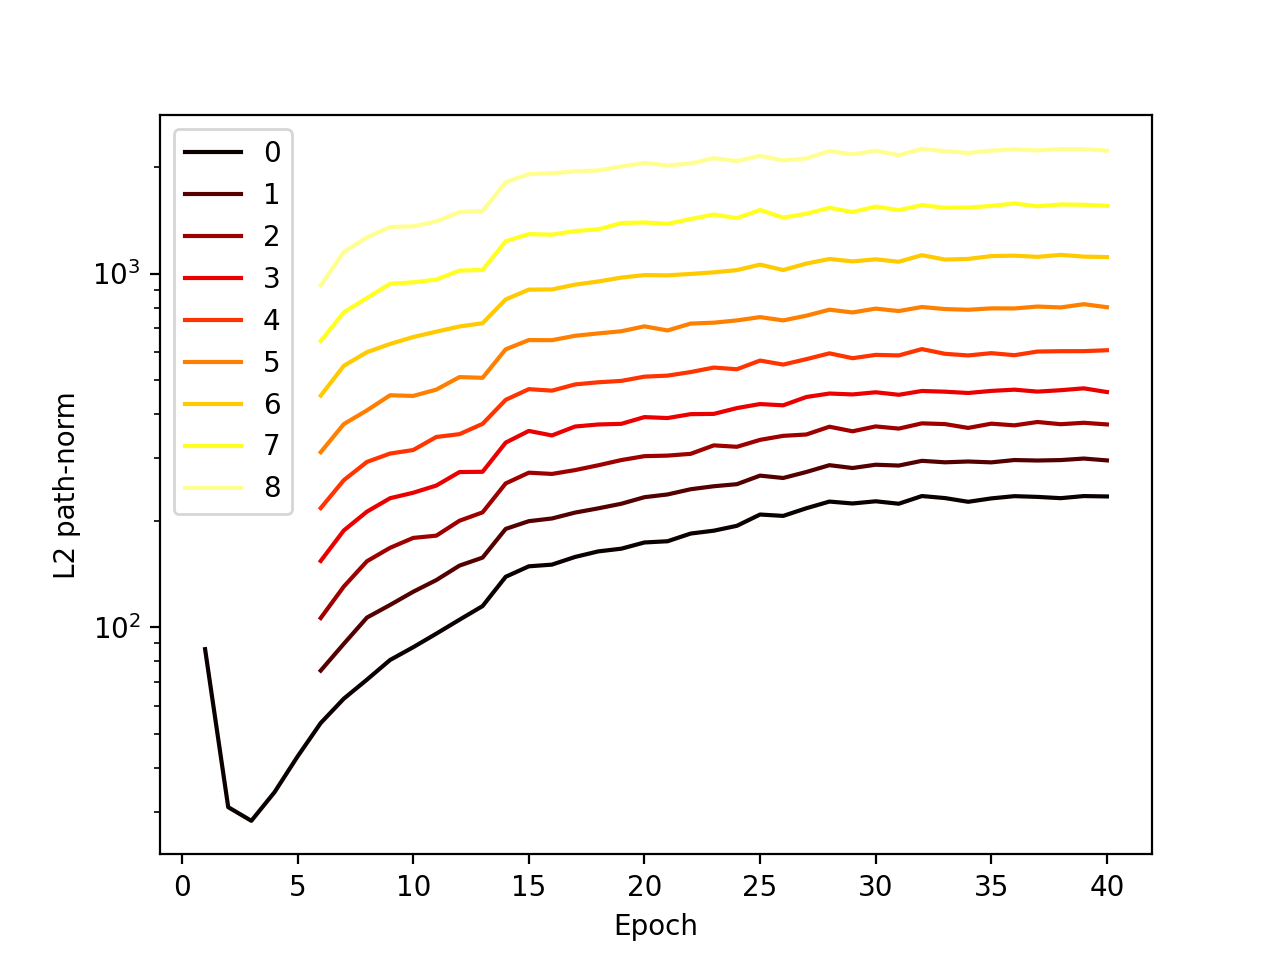
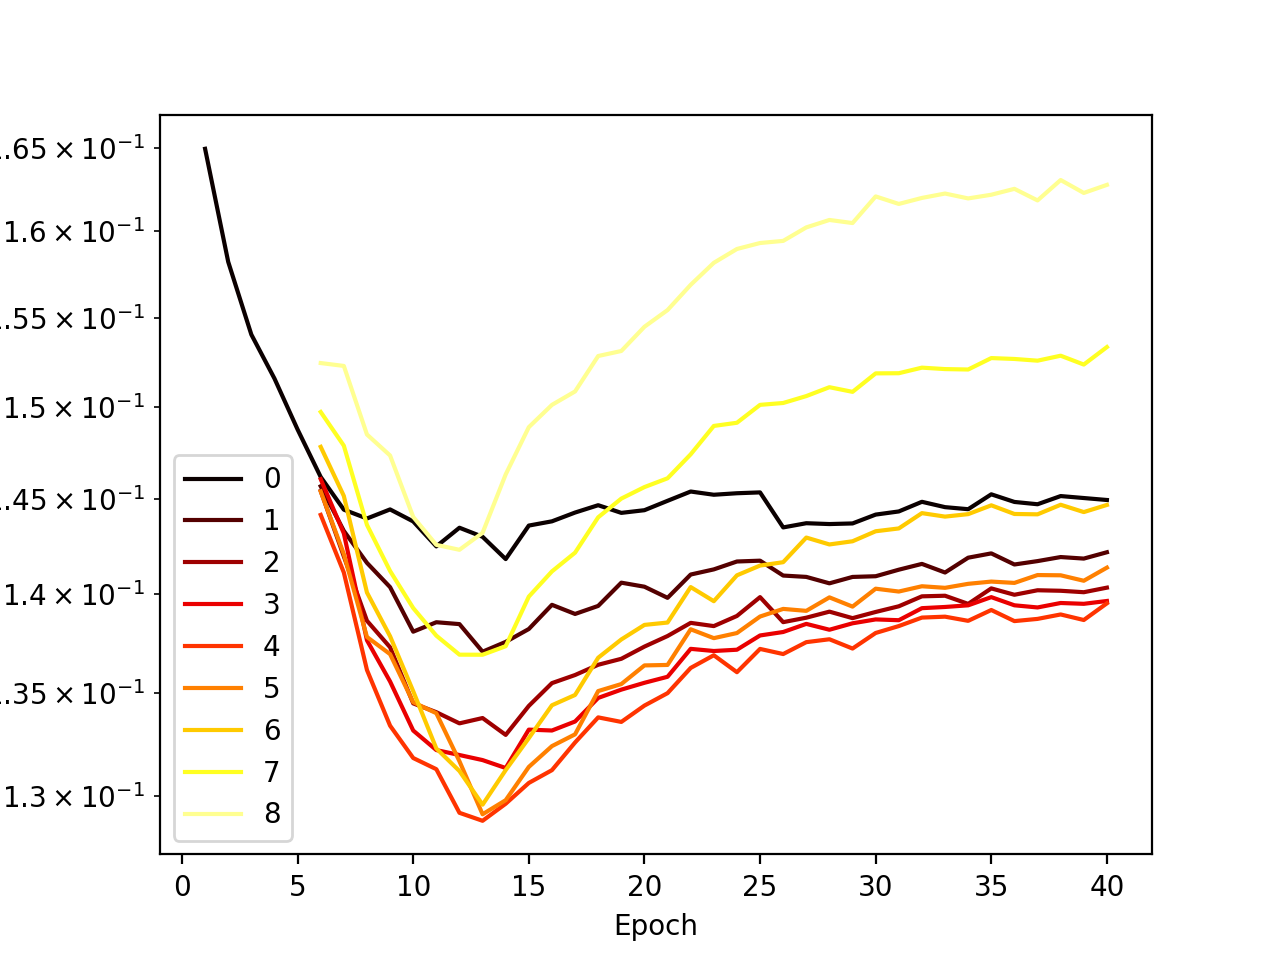
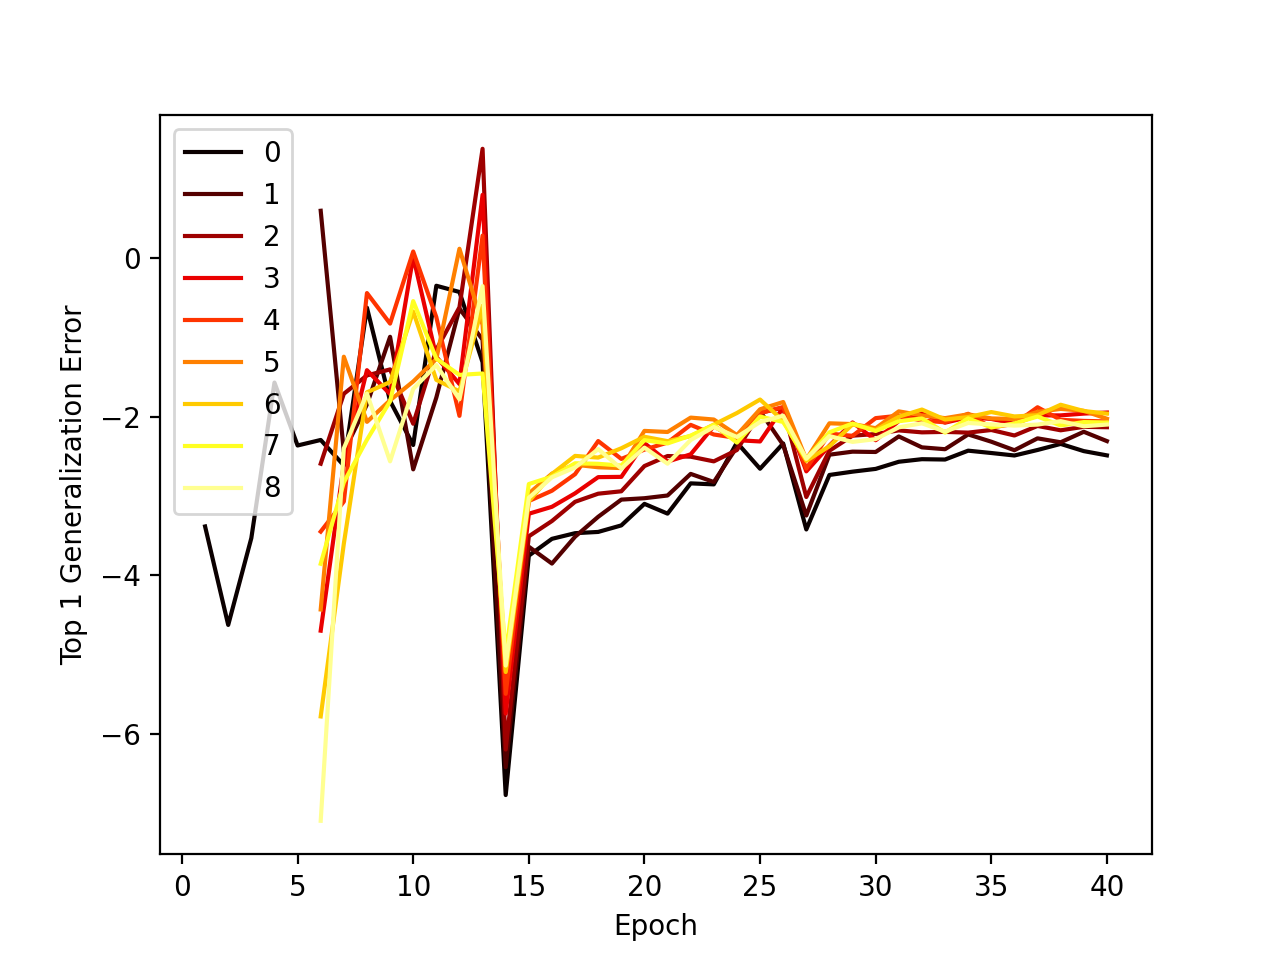
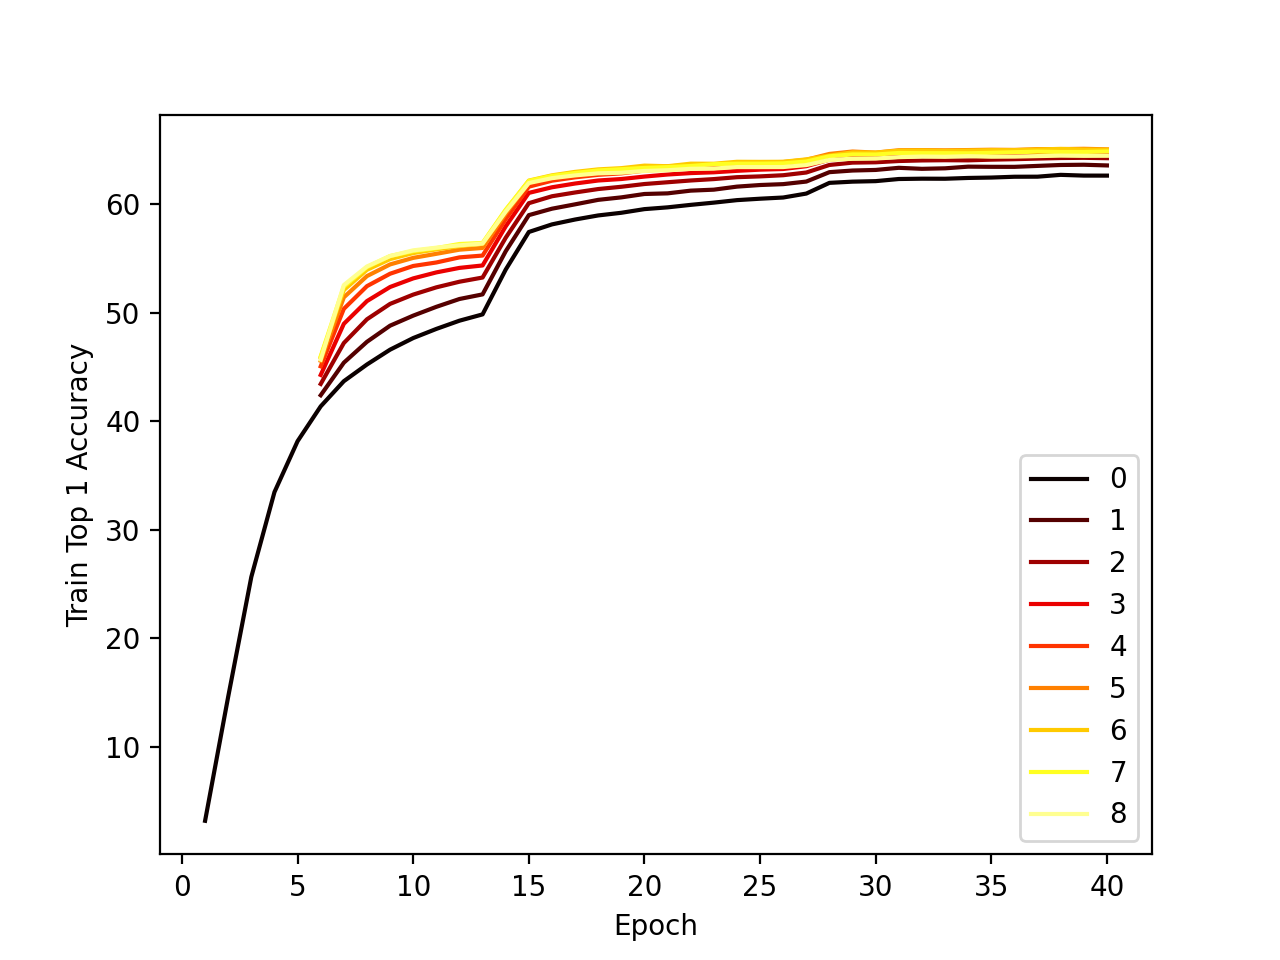
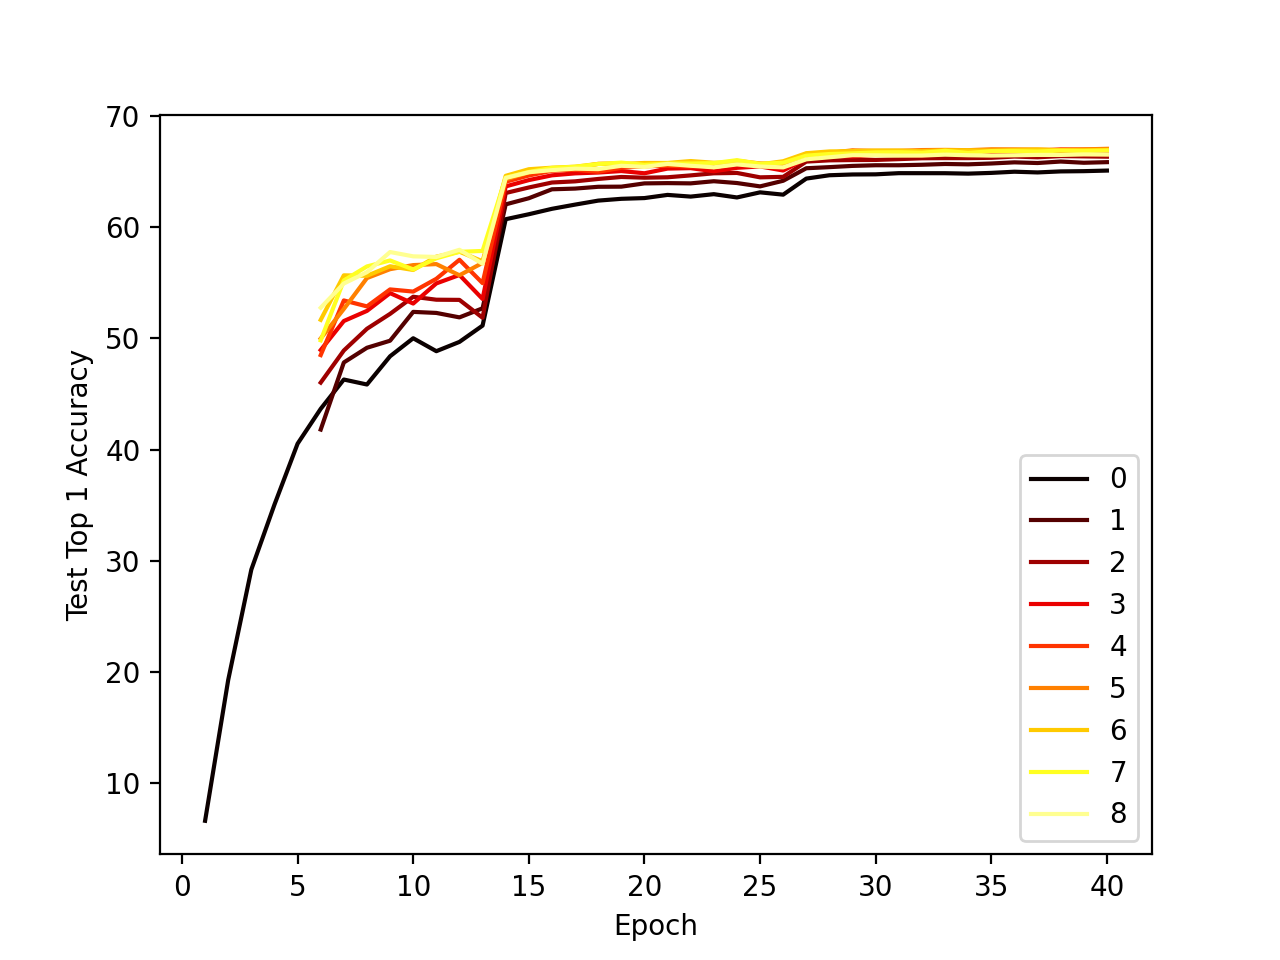

In [6]:
imp_csv = find_imp_results_csv(FIGURE4_RESULTS_ROOT)

if imp_csv is None:
    print('No Figure 4 result was found under the selected source.')
    display_command_block(
        'Figure 4 rerun (40 epochs, 8 pruning iterations)',
        figure4_downscaled_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
    display_command_block(
        'Figure 4 rerun (90 epochs, 20 pruning iterations)',
        figure4_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
else:
    imp_meta = describe_imp_results_csv(imp_csv)
    print('Using Figure 4 results from', repo_relative_path(imp_csv))
    print(
        f"Figure 4 settings: epochs={imp_meta['epochs']}, "
        f"pruning iterations={imp_meta['imp_iters']}, rank={imp_meta['rank']}"
    )
    imp_df = load_imp_training_dataframe(imp_csv)
    imp_final_df = summarize_imp_final_epochs(imp_df)
    figure4_plot_dir = find_figure4_plot_dir(FIGURE4_RESULTS_ROOT)
    display(imp_final_df.style.format({
        'test/acc1': '{:.3f}',
        'train/acc1': '{:.3f}',
        'generalization_error_top1': '{:.3f}',
        'pathnorm1': '{:.3e}',
        'pathnorm2': '{:.3e}',
        'pathnorm4': '{:.3e}',
    }))
    if figure4_plot_dir is None:
        print('Saved Figure 4 plots were not found under the selected source.')
        print('The training CSV is available, but the paper-style PDFs are missing.')
    else:
        show_saved_plot_bundle(figure4_plot_dir, FIGURE4_PAPER_PDFS, columns=2, height=320)


In [7]:
IMP_DOWNSCALED_DIR = RERUN_RESULTS_ROOT / 'mid_scale' / '2_train_imp' / 'seed=0' / 'resnet18' / 'lr=0.1_wd=0.0001_epochs=40_scheduler=multi-step_percentage_pruning=0.2_imp_iters=8'
IMP_FULL_DIR = RERUN_RESULTS_ROOT / '2_train_imp' / 'seed=0' / 'resnet18' / 'lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=0.2_imp_iters=20'

if RUN_IMP_DOWNSCALED and RUN_IMP_FULL:
    raise RuntimeError('Choose either RUN_IMP_DOWNSCALED or RUN_IMP_FULL, not both.')

if (RUN_IMP_DOWNSCALED or RUN_IMP_FULL) and not ALLOW_INTERACTIVE_LONG_RERUN:
    print('Long Figure 4 runs stay off by default in the notebook.')
    display_command_block(
        'Figure 4 rerun (40 epochs, 8 pruning iterations)',
        figure4_downscaled_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
    display_command_block(
        'Figure 4 rerun (90 epochs, 20 pruning iterations)',
        figure4_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
elif RUN_IMP_DOWNSCALED or RUN_IMP_FULL:
    require_imagenet(IMAGENET_DIR, hf_cache_dir=HF_IMAGENET_CACHE_DIR)
    saving_dir = IMP_DOWNSCALED_DIR if RUN_IMP_DOWNSCALED else IMP_FULL_DIR
    plot_dir = (
        RERUN_RESULTS_ROOT / 'mid_scale' / '3_plot_imp' / 'num_seeds=1' / 'resnet18' / 'lr=0.1_wd=0.0001_epochs=40_scheduler=multi-step_percentage_pruning=0.2_imp_iters=8'
        if RUN_IMP_DOWNSCALED
        else RERUN_RESULTS_ROOT / '3_plot_imp' / 'num_seeds=1' / 'resnet18' / 'lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=0.2_imp_iters=20'
    )
    train_env = {
        'DATA_DIR': IMAGENET_DIR,
        'SAVING_DIR': saving_dir,
        'ARCH': 'resnet18',
        'WORKERS': 16,
        'BATCH_SIZE': 1024,
        'EPOCHS': 40 if RUN_IMP_DOWNSCALED else 90,
        'IMP_ITERS': 8 if RUN_IMP_DOWNSCALED else 20,
        'PERCENTAGE_PRUNING': 0.2,
        'SEED': 0,
        'LR': 0.1,
        'WD': 0.0001,
        'LR_SCHEDULER': 'multi-step',
        'USE_TENSORBOARD': 0,
    }
    plot_env = {
        'RESULTS_TRAINING_DIR': saving_dir,
        'SAVING_DIR': plot_dir,
        'NUM_SEEDS': 1,
        'RANK': 0,
        'ARCH': 'resnet18',
        'EPOCHS': train_env['EPOCHS'],
        'IMP_ITERS': train_env['IMP_ITERS'],
        'PERCENTAGE_PRUNING': train_env['PERCENTAGE_PRUNING'],
        'LR': train_env['LR'],
        'WD': train_env['WD'],
        'LR_SCHEDULER': train_env['LR_SCHEDULER'],
    }
    run_command(['bash', str(iclr24_wrapper_script(REPO_ROOT, 'run_figure4_train.sh'))], repo_root=REPO_ROOT, env=train_env)
    run_command(['bash', str(iclr24_wrapper_script(REPO_ROOT, 'run_figure4_plot.sh'))], repo_root=REPO_ROOT, env=plot_env)
else:
    display_command_block(
        'Figure 4 rerun (40 epochs, 8 pruning iterations)',
        figure4_downscaled_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
    display_command_block(
        'Figure 4 rerun (90 epochs, 20 pruning iterations)',
        figure4_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )


**Figure 4 rerun (40 epochs, 8 pruning iterations)**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
SAVING_DIR="repro/iclr24/results/rerun/mid_scale/2_train_imp/seed=0/resnet18/lr=0.1_wd=0.0001_epochs=40_scheduler=multi-step_percentage_pruning=0.2_imp_iters=8" \
ARCH=resnet18 \
WORKERS=16 \
BATCH_SIZE=1024 \
EPOCHS=40 \
IMP_ITERS=8 \
PERCENTAGE_PRUNING=0.2 \
SEED=0 \
LR=0.1 \
WD=0.0001 \
LR_SCHEDULER=multi-step \
bash repro/iclr24/utils/run_figure4_train.sh

RESULTS_TRAINING_DIR="repro/iclr24/results/rerun/mid_scale/2_train_imp/seed=0/resnet18/lr=0.1_wd=0.0001_epochs=40_scheduler=multi-step_percentage_pruning=0.2_imp_iters=8" \
SAVING_DIR="repro/iclr24/results/rerun/mid_scale/3_plot_imp/num_seeds=1/resnet18/lr=0.1_wd=0.0001_epochs=40_scheduler=multi-step_percentage_pruning=0.2_imp_iters=8" \
NUM_SEEDS=1 \
RANK=-1 \
ARCH=resnet18 \
EPOCHS=40 \
IMP_ITERS=8 \
PERCENTAGE_PRUNING=0.2 \
LR=0.1 \
WD=0.0001 \
LR_SCHEDULER=multi-step \
bash repro/iclr24/utils/run_figure4_plot.sh
```

**Figure 4 rerun (90 epochs, 20 pruning iterations)**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
SAVING_DIR="repro/iclr24/results/rerun/2_train_imp/seed=0/resnet18/lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=0.2_imp_iters=20" \
ARCH=resnet18 \
WORKERS=16 \
BATCH_SIZE=1024 \
EPOCHS=90 \
IMP_ITERS=20 \
PERCENTAGE_PRUNING=0.2 \
SEED=0 \
LR=0.1 \
WD=0.0001 \
LR_SCHEDULER=multi-step \
bash repro/iclr24/utils/run_figure4_train.sh

RESULTS_TRAINING_DIR="repro/iclr24/results/rerun/2_train_imp/seed=0/resnet18/lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=0.2_imp_iters=20" \
SAVING_DIR="repro/iclr24/results/rerun/3_plot_imp/num_seeds=1/resnet18/lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=0.2_imp_iters=20" \
NUM_SEEDS=1 \
RANK=-1 \
ARCH=resnet18 \
EPOCHS=90 \
IMP_ITERS=20 \
PERCENTAGE_PRUNING=0.2 \
LR=0.1 \
WD=0.0001 \
LR_SCHEDULER=multi-step \
bash repro/iclr24/utils/run_figure4_plot.sh
```

## Figure 5: increasing the ImageNet train size

By default this section reads the included Figure 5 results and shows the saved paper-style plots. The included bundle uses `1` seed. To inspect your own rerun, point `FIGURE5_RESULTS_ROOT` to that results root.


Using Figure 5 results from repro/iclr24/results/paper_release
Figure 5 settings: epochs=90 seeds=1 dataset sizes=[39636, 79272, 158544, 317089, 634178]


,size_dataset,size_fraction,epoch,test/acc1,train/acc1,generalization_error_top1,generalization_error_ce,pathnorm1
0,39636,1/32,90,23.234,65.529,42.295,2.577,2.835e+27
1,79272,1/16,90,35.586,69.398,33.812,1.864,8.677e+27
2,158544,1/8,90,47.960,71.129,23.169,1.174,3.630e+28
3,317089,1/4,90,57.978,70.680,12.702,0.588,1.314e+29
4,634178,1/2,90,64.954,70.339,5.385,0.197,4.931e+29


Showing saved paper-style plots from repro/iclr24/results/paper_release/5_plot_increasing_dataset/num_seeds=1/resnet18/lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=_imp_iters=0



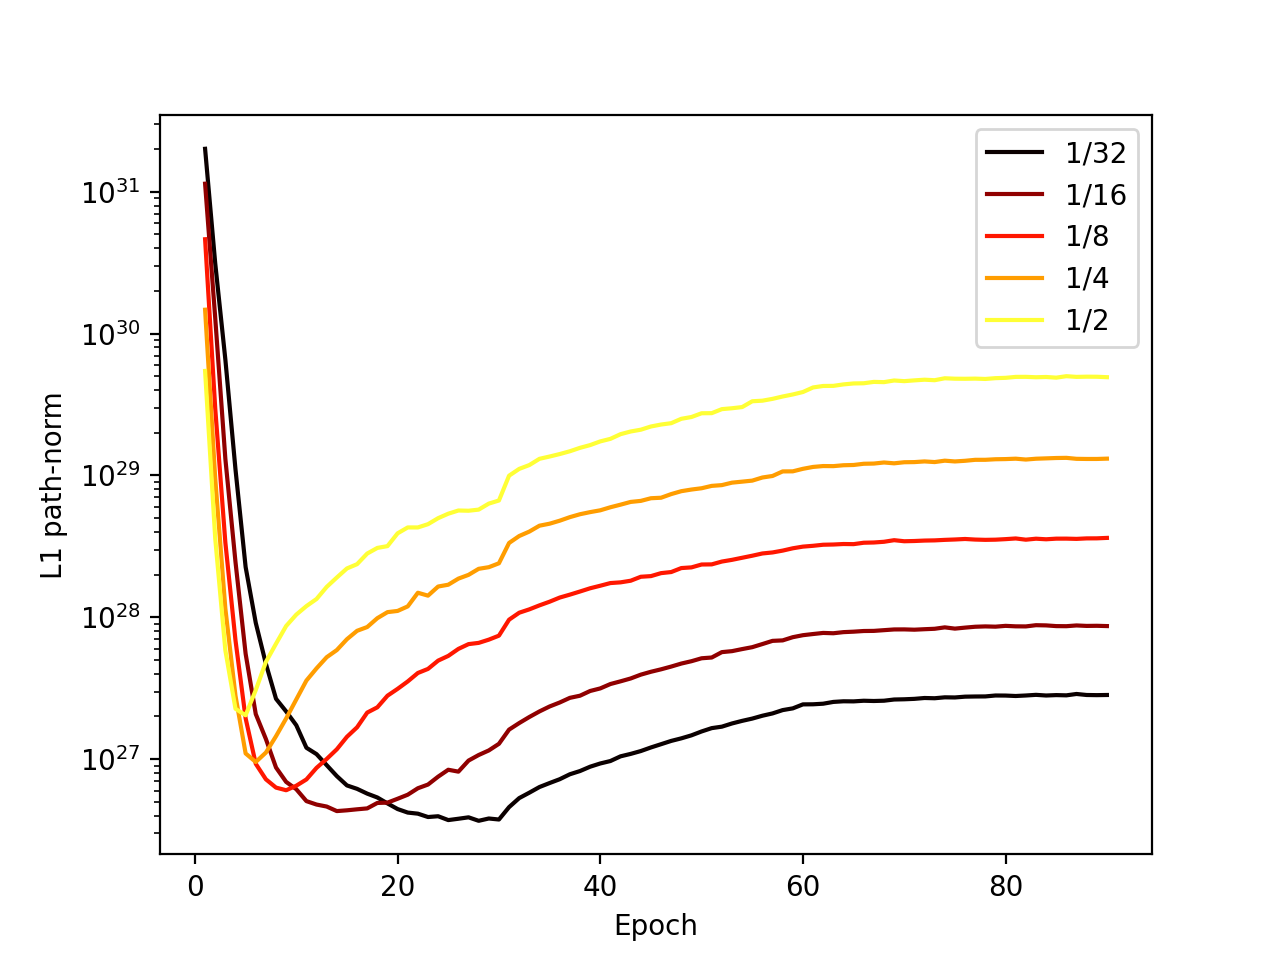
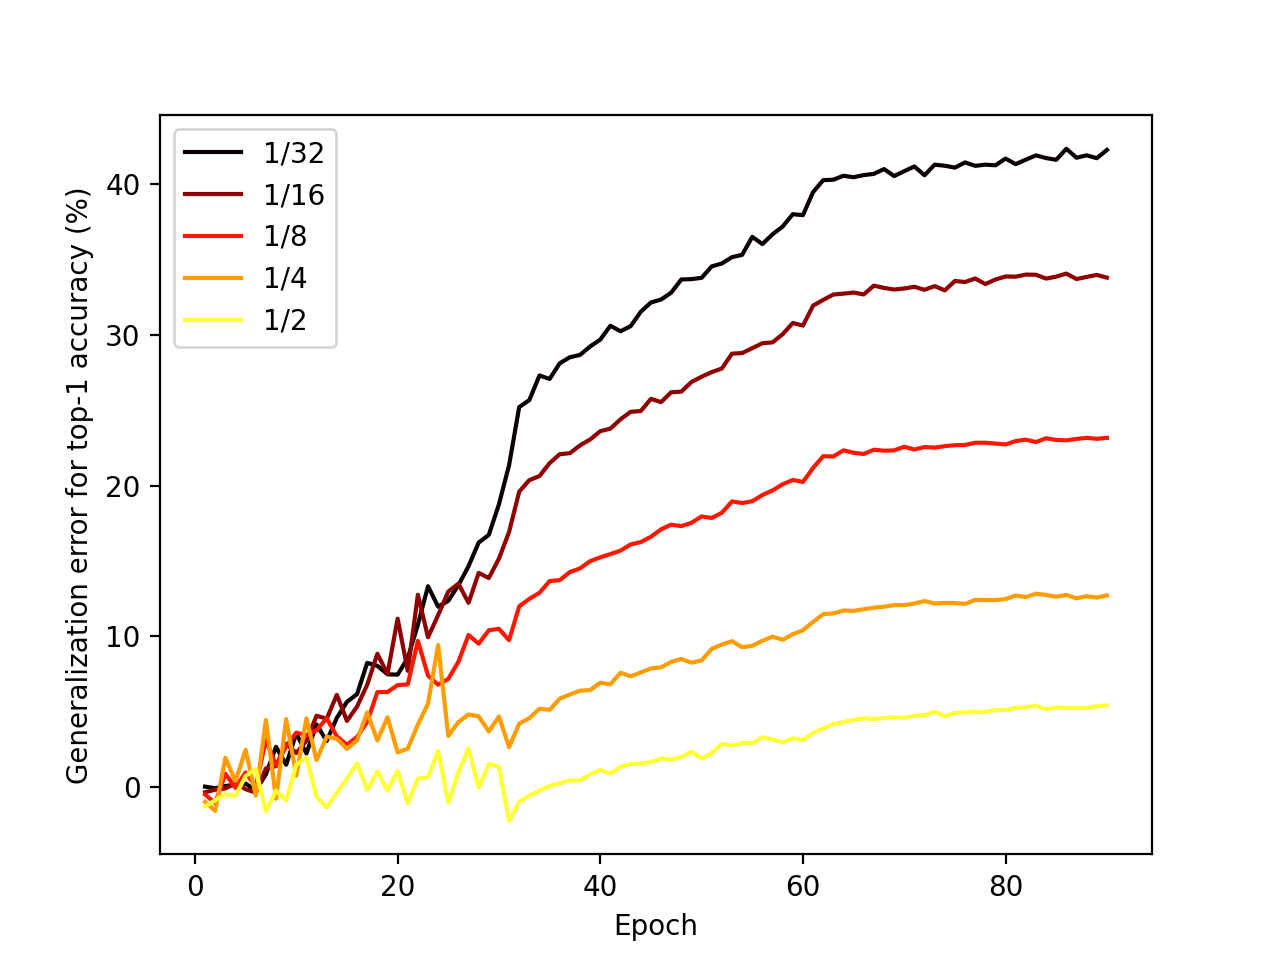
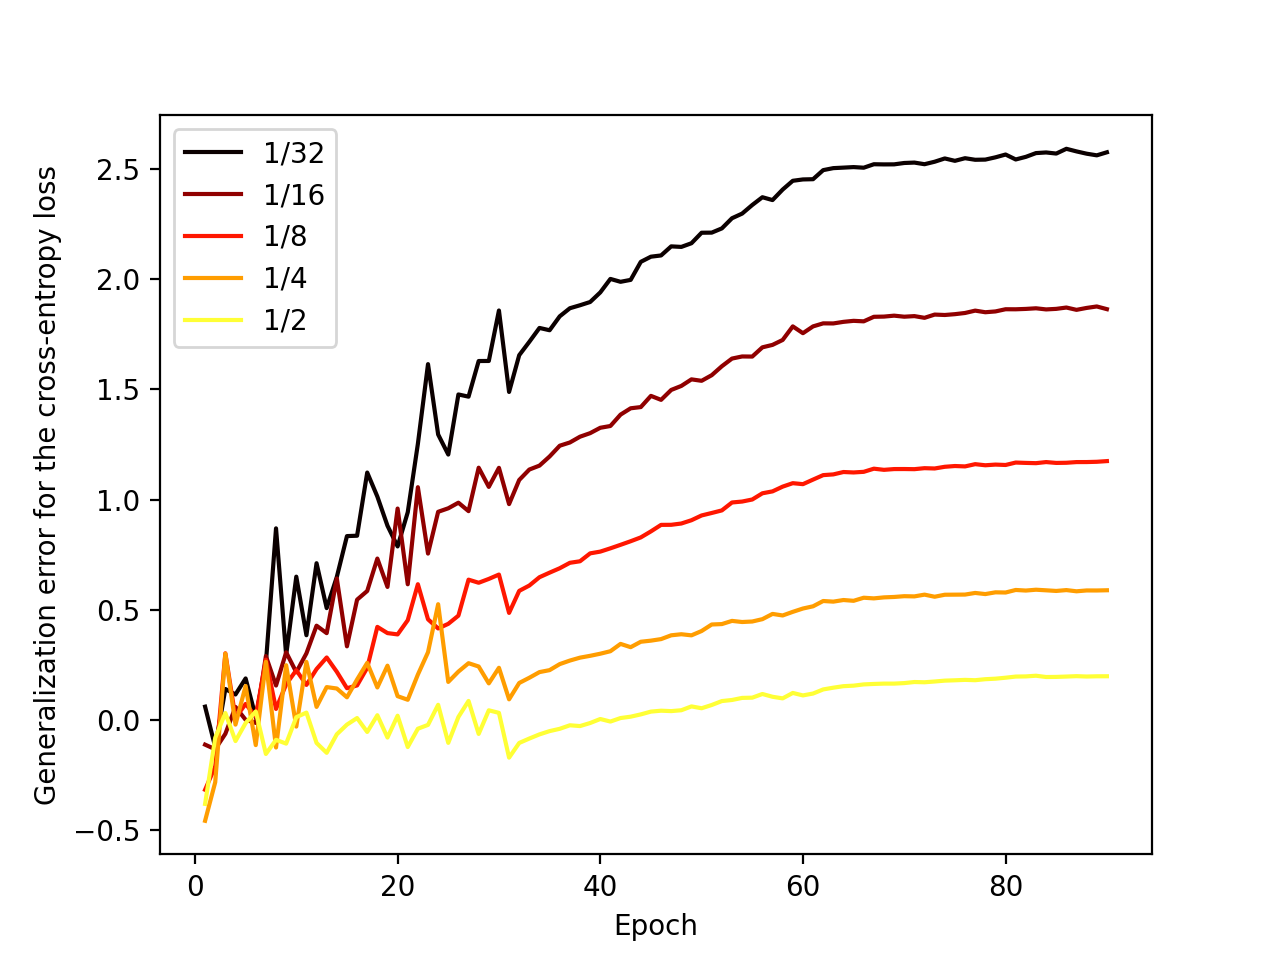

In [8]:
increasing_manifest = describe_increasing_dataset_results_root(FIGURE5_RESULTS_ROOT)
increasing_df = load_increasing_dataset_dataframe(FIGURE5_RESULTS_ROOT)

if increasing_df.empty:
    print('No Figure 5 training CSVs were found under the selected source.')
    display_command_block(
        'Figure 5 rerun (1 seed)',
        figure5_downscaled_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
    display_command_block(
        'Figure 5 rerun (3 seeds)',
        figure5_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
else:
    print('Using Figure 5 results from', repo_relative_path(FIGURE5_RESULTS_ROOT))
    print(
        'Figure 5 settings:',
        f"epochs={increasing_manifest['num_epochs']}",
        f"seeds={increasing_manifest['num_seeds']}",
        f"dataset sizes={increasing_manifest['dataset_sizes']}",
    )
    increasing_final_df = summarize_increasing_dataset_final_epoch(increasing_df)
    figure5_plot_dir = find_figure5_plot_dir(FIGURE5_RESULTS_ROOT)
    display(increasing_final_df.style.format({
        'test/acc1': '{:.3f}',
        'train/acc1': '{:.3f}',
        'generalization_error_top1': '{:.3f}',
        'generalization_error_ce': '{:.3f}',
        'pathnorm1': '{:.3e}',
    }))
    if figure5_plot_dir is None:
        print('Saved Figure 5 plots were not found under the selected source.')
        print('The training CSVs are available, but the paper-style PDFs are missing.')
    else:
        show_saved_plot_bundle(figure5_plot_dir, FIGURE5_PAPER_PDFS, columns=2, height=340)


In [9]:
INCREASING_DOWNSCALED_DIR = RERUN_RESULTS_ROOT / 'mid_scale' / '4_train_increasing_dataset'
INCREASING_FULL_DIR = RERUN_RESULTS_ROOT / '4_train_increasing_dataset'

if RUN_INCREASING_DOWNSCALED and RUN_INCREASING_FULL:
    raise RuntimeError('Choose either RUN_INCREASING_DOWNSCALED or RUN_INCREASING_FULL, not both.')

if (RUN_INCREASING_DOWNSCALED or RUN_INCREASING_FULL) and not ALLOW_INTERACTIVE_LONG_RERUN:
    print('Long Figure 5 runs stay off by default in the notebook.')
    display_command_block(
        'Figure 5 rerun (1 seed)',
        figure5_downscaled_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
    display_command_block(
        'Figure 5 rerun (3 seeds)',
        figure5_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
elif RUN_INCREASING_DOWNSCALED or RUN_INCREASING_FULL:
    require_imagenet(IMAGENET_DIR, hf_cache_dir=HF_IMAGENET_CACHE_DIR)
    saving_root = INCREASING_DOWNSCALED_DIR if RUN_INCREASING_DOWNSCALED else INCREASING_FULL_DIR
    train_env = {
        'DATA_DIR': IMAGENET_DIR,
        'SAVING_ROOT': saving_root,
        'ARCH': 'resnet18',
        'WORKERS': 16,
        'BATCH_SIZE': 512 if RUN_INCREASING_DOWNSCALED else 1024,
        'EPOCHS': 90,
        'SEEDS': '0' if RUN_INCREASING_DOWNSCALED else '0 1 2',
        'SIZE_DATASETS': '39636 79272 158544 317089 634178',
        'LR': 0.1,
        'WD': 0.0001,
        'LR_SCHEDULER': 'multi-step',
        'USE_TENSORBOARD': 0,
    }
    run_command(['bash', str(iclr24_wrapper_script(REPO_ROOT, 'run_figure5_train.sh'))], repo_root=REPO_ROOT, env=train_env)
    plot_env = {
        'RESULTS_TRAINING_DIR': saving_root / 'seed=0' / 'resnet18' / 'size_dataset=39636' / 'lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=_imp_iters=0',
        'SAVING_DIR': (
            RERUN_RESULTS_ROOT / 'mid_scale' / '5_plot_increasing_dataset' / 'num_seeds=1' / 'resnet18' / 'lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=_imp_iters=0'
            if RUN_INCREASING_DOWNSCALED
            else RERUN_RESULTS_ROOT / '5_plot_increasing_dataset' / 'num_seeds=3' / 'resnet18' / 'lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=_imp_iters=0'
        ),
        'NUM_EPOCHS': 90,
        'NUM_SEEDS': 1 if RUN_INCREASING_DOWNSCALED else 3,
        'RANK': 0,
        'ARCH': 'resnet18',
        'LR': train_env['LR'],
        'WD': train_env['WD'],
        'LR_SCHEDULER': train_env['LR_SCHEDULER'],
    }
    run_command(['bash', str(iclr24_wrapper_script(REPO_ROOT, 'run_figure5_plot.sh'))], repo_root=REPO_ROOT, env=plot_env)
else:
    display_command_block(
        'Figure 5 rerun (1 seed)',
        figure5_downscaled_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )
    display_command_block(
        'Figure 5 rerun (3 seeds)',
        figure5_rerun_command(IMAGENET_DIR, RERUN_RESULTS_ROOT),
    )


**Figure 5 rerun (1 seed)**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
SAVING_ROOT="repro/iclr24/results/rerun/mid_scale/4_train_increasing_dataset" \
ARCH=resnet18 \
WORKERS=16 \
BATCH_SIZE=512 \
EPOCHS=90 \
IMP_ITERS=0 \
SEEDS="0" \
SIZE_DATASETS="39636 79272 158544 317089 634178" \
LR=0.1 \
WD=0.0001 \
LR_SCHEDULER=multi-step \
USE_TENSORBOARD=0 \
bash repro/iclr24/utils/run_figure5_train.sh

RESULTS_TRAINING_DIR="repro/iclr24/results/rerun/mid_scale/4_train_increasing_dataset/seed=0/resnet18/size_dataset=39636/lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=_imp_iters=0" \
SAVING_DIR="repro/iclr24/results/rerun/mid_scale/5_plot_increasing_dataset/num_seeds=1/resnet18/lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=_imp_iters=0" \
NUM_EPOCHS=90 \
NUM_SEEDS=1 \
RANK=0 \
ARCH=resnet18 \
LR=0.1 \
WD=0.0001 \
LR_SCHEDULER=multi-step \
bash repro/iclr24/utils/run_figure5_plot.sh
```

**Figure 5 rerun (3 seeds)**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
SAVING_ROOT="repro/iclr24/results/rerun/4_train_increasing_dataset" \
ARCH=resnet18 \
WORKERS=16 \
BATCH_SIZE=1024 \
EPOCHS=90 \
IMP_ITERS=0 \
SEEDS="0 1 2" \
SIZE_DATASETS="39636 79272 158544 317089 634178" \
LR=0.1 \
WD=0.0001 \
LR_SCHEDULER=multi-step \
USE_TENSORBOARD=0 \
bash repro/iclr24/utils/run_figure5_train.sh

RESULTS_TRAINING_DIR="repro/iclr24/results/rerun/4_train_increasing_dataset/seed=0/resnet18/size_dataset=39636/lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=_imp_iters=0" \
SAVING_DIR="repro/iclr24/results/rerun/5_plot_increasing_dataset/num_seeds=3/resnet18/lr=0.1_wd=0.0001_epochs=90_scheduler=multi-step_percentage_pruning=_imp_iters=0" \
NUM_EPOCHS=90 \
NUM_SEEDS=3 \
RANK=0 \
ARCH=resnet18 \
LR=0.1 \
WD=0.0001 \
LR_SCHEDULER=multi-step \
bash repro/iclr24/utils/run_figure5_plot.sh
```

## Appendix: pretrained margin quantiles and histograms

By default this section reuses the saved margin tensors in `repro/iclr24/results/paper_release/1_compute_pretrained_pathnorm_margins_resnets`.

To recompute them on ImageNet, set `RUN_PRETRAINED_MARGIN_RERUN = True`.


In [10]:
if RUN_PRETRAINED_MARGIN_RERUN:
    require_imagenet(IMAGENET_DIR, hf_cache_dir=HF_IMAGENET_CACHE_DIR)
    margin_env = {
        'DATA_DIR': IMAGENET_DIR,
        'SAVING_DIR': RERUN_PRETRAINED_ROOT,
        'MARGINS_ALREADY_COMPUTED': 0,
        'WORKERS': 16,
        'BATCH_SIZE': 1024,
    }
    run_command(['bash', str(iclr24_wrapper_script(REPO_ROOT, 'run_pretrained_resnets.sh'))], repo_root=REPO_ROOT, env=margin_env)

rerun_margin_available = (RERUN_PRETRAINED_ROOT / 'resnet18' / 'margins.pt').exists()
paper_margin_available = (PAPER_PRETRAINED_ROOT / 'resnet18' / 'margins.pt').exists()
margin_root = (
    RERUN_PRETRAINED_ROOT
    if rerun_margin_available
    else PAPER_PRETRAINED_ROOT if paper_margin_available else None
)
margin_df = summarize_margin_quantiles(margin_root) if margin_root is not None else pd.DataFrame()
if margin_df.empty:
    print('No saved margin tensors were found yet. Set RUN_PRETRAINED_MARGIN_RERUN = True to compute them from ImageNet.')
else:
    if margin_root == PAPER_PRETRAINED_ROOT and not RUN_PRETRAINED_MARGIN_RERUN:
        print('Using the included margin tensor bundle.')
    else:
        print('Using saved margin tensors from', repo_relative_path(margin_root))
    display(margin_df.style.format({col: '{:.4f}' for col in margin_df.columns if col != 'arch'}))


Using the included margin tensor bundle.


,arch,train_top1,margin_q=e,margin_q=2e/3+1/3,margin_q=(e+1)/2,margin_q=e/3+2/3,margin_q=1,margin_min,margin_median,margin_max
0,resnet18,0.7932,0.0000,2.4060,3.5953,5.0254,31.6699,-27.8198,2.6541,31.6699
1,resnet34,0.8469,0.0000,2.8057,4.1104,5.6395,35.6234,-21.0323,3.3862,35.6234
2,resnet50,0.9131,0.0000,2.5524,3.3823,4.1536,15.3879,-8.1392,3.1540,15.3879
3,resnet101,0.9448,0.0001,3.6983,4.7217,5.6281,15.7519,-9.1070,4.5539,15.7519
4,resnet152,0.9529,0.0000,3.9275,4.9510,5.8352,21.1905,-8.4918,4.8110,21.1905
